In [1]:
# 2.1 Loading Necessary Libraries
import numpy as np  # linear algebra
import pandas as pd  # data processing
import matplotlib.pyplot as plt  # For basic data visualization.
import seaborn as sns  # For statistical data visualization
import warnings  # To manage warnings

# Suppressing FutureWarning
warnings.filterwarnings("ignore")

# 2.2 Loading Dataets
train_df = pd.read_csv(
    "../data/spaceship-titanic/train.csv"
)
test_df = pd.read_csv(
    "../data/spaceship-titanic/test.csv"
)

# Let's quickly check the data by viewing the first few rows.
print(train_df.head())
print(test_df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
  

In [2]:
train_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [3]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [4]:
# 2.4 Missing Data Analysis

# Let's create a DataFrame to calculate the number and percentage of missing values
def missing_data_table(df):
    total = df.isnull().sum().sort_values(ascending=False) # Total missing values in each column.
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False) # Percentage of missing values.

    missing_data = pd.concat([total, percent], axis=1, keys=["Total", "Percent"]) # Combine the results.

    # Filter columns that actually have missing values.
    return missing_data[missing_data["Total"] > 0] 

# Display missing data for the training dataset.
missing_train = missing_data_table(train_df)
missing_train

,Total,Percent
CryoSleep,217,0.024963
ShoppingMall,208,0.023927
VIP,203,0.023352
HomePlanet,201,0.023122
Name,200,0.023007
Cabin,199,0.022892
VRDeck,188,0.021627
Spa,183,0.021051
FoodCourt,183,0.021051
Destination,182,0.020936


In [5]:
missing_test = missing_data_table(test_df)
missing_test

,Total,Percent
FoodCourt,106,0.024784
Spa,101,0.023615
Cabin,100,0.023381
ShoppingMall,98,0.022913
Name,94,0.021978
VIP,93,0.021744
CryoSleep,93,0.021744
Destination,92,0.021510
Age,91,0.021277
HomePlanet,87,0.020341


<Axes: xlabel='Transported', ylabel='count'>

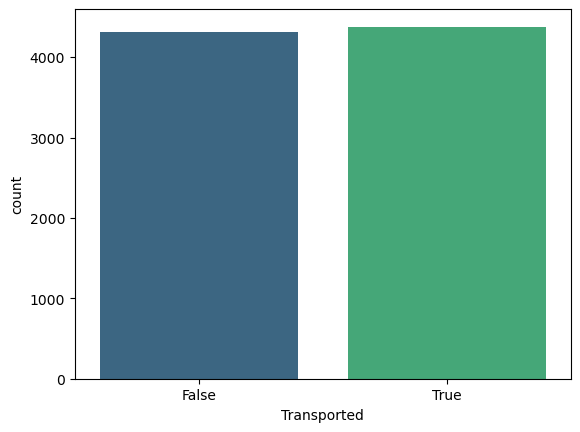

In [6]:
sns.countplot(x="Transported", data=train_df, palette="viridis")

Text(0.5, 1.0, 'Cyro Sleep vs Transported')

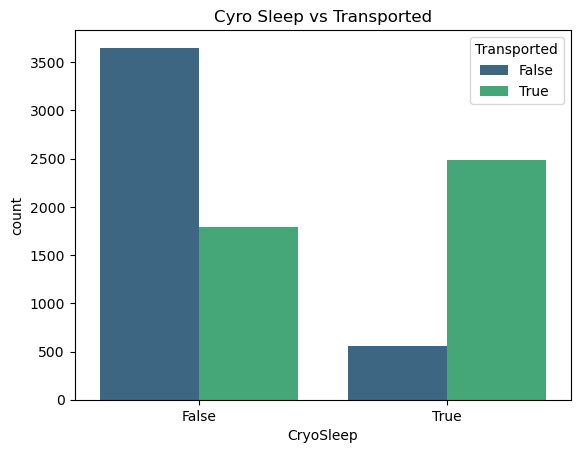

In [7]:
sns.countplot(data=train_df, x="CryoSleep", hue="Transported", palette="viridis")
plt.title("Cyro Sleep vs Transported")

Text(0.5, 1.0, 'HomePlanet vs Transported')

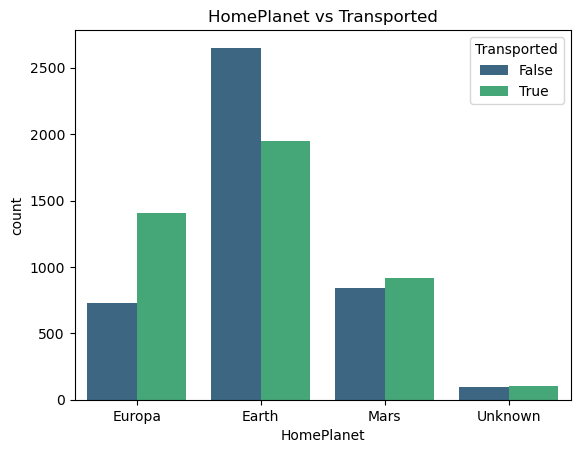

In [38]:
visualize_df = train_df.copy()
visualize_df['HomePlanet'] = visualize_df['HomePlanet'].fillna('Unknown')

sns.countplot(data=visualize_df, x="HomePlanet", hue="Transported", palette="viridis")
plt.title("HomePlanet vs Transported")

In [39]:
visualize_df['PassengerGroup'] = visualize_df['PassengerId'].str.split('_').str[0]

unique_groups = visualize_df['PassengerGroup'].unique()
print(len(unique_groups))
print(unique_groups)

# sns.countplot(data=visualize_df, x="PassengerGroup", hue="Transported", palette="viridis")
# plt.title("PassengerGroup vs Transported")

6217
['0001' '0002' '0003' ... '9278' '9279' '9280']


In [15]:
group_counts = visualize_df['PassengerGroup'].value_counts()
print(group_counts.describe())

count    6217.000000
mean        1.398263
std         0.944051
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         8.000000
Name: count, dtype: float64


<Axes: xlabel='Transported', ylabel='PassengerGroup_size'>

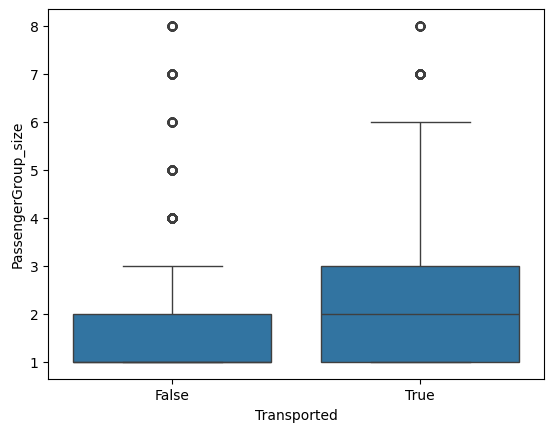

In [40]:
# Create a new feature: 'group_size'
visualize_df['PassengerGroup_size'] = visualize_df.groupby('PassengerGroup')['PassengerGroup'].transform('count')

# Now plot this against your boolean label
sns.boxplot(data=visualize_df, x='Transported', y='PassengerGroup_size')

In [41]:
def categorize_group(size):
    if size == 1:
        return "Solo"
    elif size <= 4:
        return "Small_Group"
    else:
        return "Large_Group"


visualize_df["PassengerGroup_type"] = visualize_df["PassengerGroup_size"].apply(categorize_group)

Text(0.5, 1.0, 'PassengerGroup_type vs Transported')

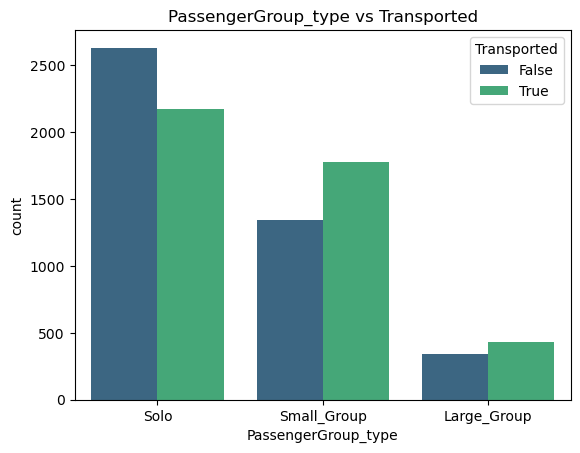

In [42]:
sns.countplot(data=visualize_df, x="PassengerGroup_type", hue="Transported", palette="viridis")
plt.title("PassengerGroup_type vs Transported")

In [43]:
def check_unique(df, col):
    unique_groups = df[col].unique()
    print(len(unique_groups))
    print(unique_groups)

In [44]:
visualize_df['CabinDeck'] = visualize_df['Cabin'].str.split('/').str[0]
visualize_df['CabinNum'] = visualize_df['Cabin'].str.split('/').str[1]
visualize_df['CabinSide'] = visualize_df['Cabin'].str.split('/').str[2]

visualize_df['CabinDeck'] = visualize_df['CabinDeck'].fillna('Unknown')
visualize_df['CabinNum'] = visualize_df['CabinNum'].fillna('Unknown')
visualize_df['CabinSide'] = visualize_df['CabinSide'].fillna('Unknown')

In [45]:
check_unique(visualize_df, 'CabinDeck')
check_unique(visualize_df, 'CabinNum')
check_unique(visualize_df, 'CabinSide')

9
['B' 'F' 'A' 'G' 'Unknown' 'E' 'D' 'C' 'T']
1818
['0' '1' '2' ... '1892' '1893' '1894']
3
['P' 'S' 'Unknown']


Text(0.5, 1.0, 'CabinDeck vs Transported')

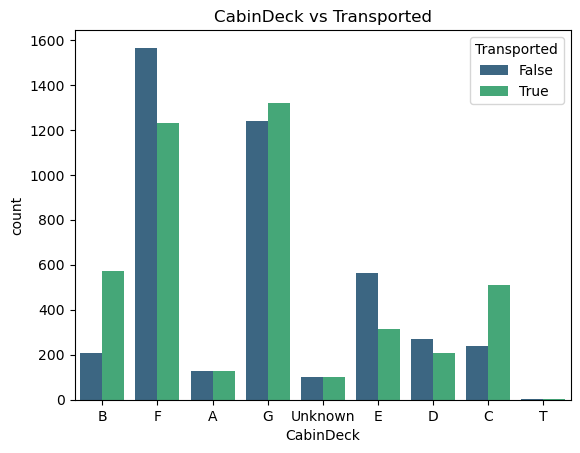

In [46]:
sns.countplot(data=visualize_df, x="CabinDeck", hue="Transported", palette="viridis")
plt.title("CabinDeck vs Transported")

Text(0.5, 1.0, 'CabinSide vs Transported')

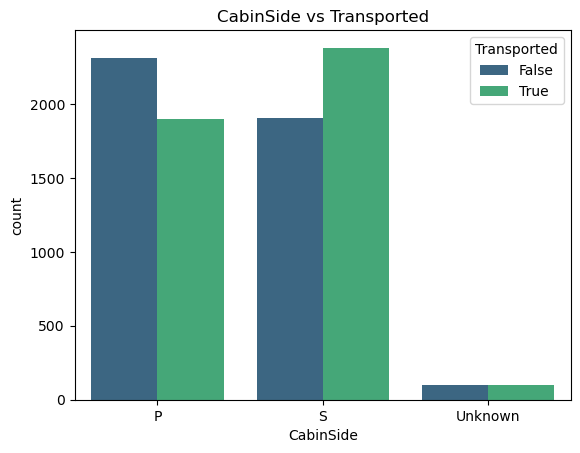

In [47]:
sns.countplot(data=visualize_df, x="CabinSide", hue="Transported", palette="viridis")
plt.title("CabinSide vs Transported")

In [48]:
visualize_df['Destination'] = visualize_df['Destination'].fillna('Unknown')
check_unique(visualize_df, 'Destination')

4
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' 'Unknown']


Text(0.5, 1.0, 'Destination vs Transported')

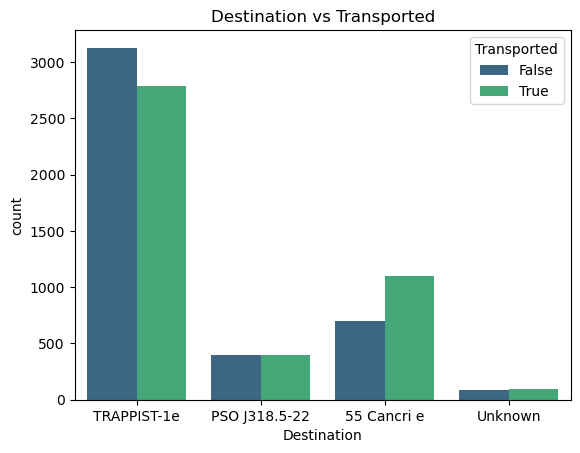

In [49]:
sns.countplot(data=visualize_df, x="Destination", hue="Transported", palette="viridis")
plt.title("Destination vs Transported")

In [50]:
visualize_df['Age'] = visualize_df['Age'].fillna(visualize_df['Age'].mode()[0])

Text(0.5, 1.0, 'Distribution of Age Feature by Target Class')

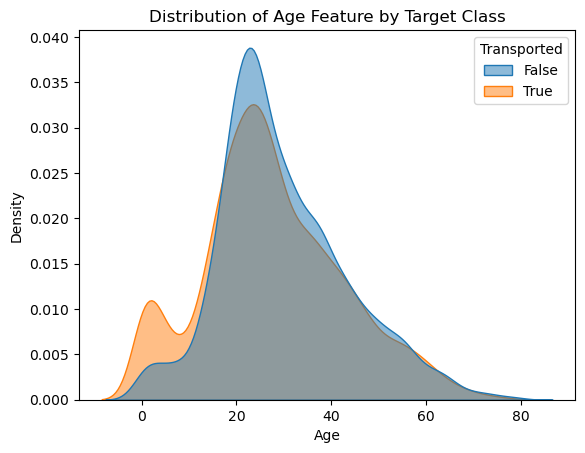

In [51]:
sns.kdeplot(data=visualize_df, x="Age", hue="Transported", fill=True, common_norm=False, alpha=0.5)
plt.title("Distribution of Age Feature by Target Class")

<Axes: xlabel='Transported', ylabel='Age'>

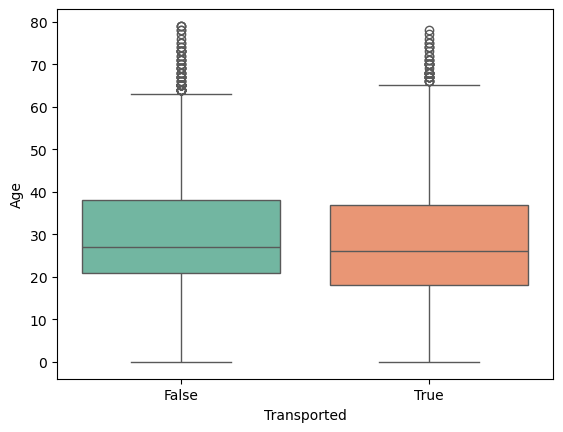

In [52]:
sns.boxplot(data=visualize_df, x="Transported", y="Age", palette="Set2")

Text(0.5, 1.0, 'VIP vs Transported')

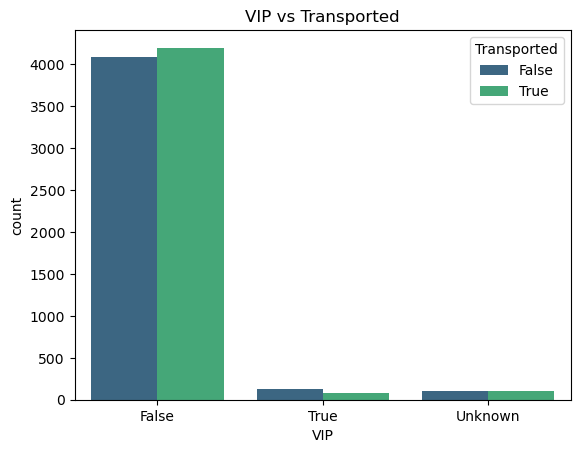

In [53]:
visualize_df['VIP'] = visualize_df['VIP'].fillna('Unknown')
sns.countplot(data=visualize_df, x="VIP", hue="Transported", palette="viridis")
plt.title("VIP vs Transported")

In [55]:
visualize_df['VIP'] = visualize_df['VIP'].apply(lambda x: 1 if x is True else 0)

In [54]:
check_unique(visualize_df, 'VIP')

3
[False True 'Unknown']


In [56]:
# Calculate the overall average of your target
global_mean = visualize_df['Transported'].mean()

# Calculate the mean per category and the distance from global mean
analysis = visualize_df.groupby('VIP')['Transported'].agg(['mean', 'count'])
analysis['diff'] = abs(analysis['mean'] - global_mean)

# If 'diff' is very small for all large 'count' groups, the column is useless.
print(analysis.sort_values(by='count', ascending=False).head(10))

         mean  count      diff
VIP                           
0    0.506475   8494  0.002852
1    0.381910    199  0.121714


In [ ]:
# Extract group from PassengerId
# HomePlanet -> Cat
# 